# 🔬 Continuous Hybrid Tracker
This notebook combines our high-resolution `numpy` FFT Transient Extractor with the powerful Localized Continuous Phase Sweep.

Here, `Listener` acts simply to **initialize a search radius**. We sweep a continuous phase float array at high resolution (0.1 BPM) in a tiny local region around what the classic Flywheel suspects the BPM is. This gives sub-BPM float precision. We then throw those projected phase beats into our Magnetic 5-Second Lookahead Buffer to snap onto the exact physical transients.


In [1]:
import librosa
import numpy as np
import torchaudio
import torch
import time
from collections import deque
import warnings
warnings.filterwarnings('ignore')

import sys
import os
sys.path.append(os.path.abspath('..'))

# Import core infrastructure
import core.Listener as ListenerModule
from IPython.display import display, clear_output

def default_infos():
    return {
        "startServer"     : False ,
        "useMicrophone"   : True  ,
        "HARDWARE_MODE"   : "simulation",
        "onRaspberry"     : False  ,

        "printTimeOfCalculation" : False ,
        "printModesDetails"      : True ,
        "printMicrophoneDetails" : False ,
        "printAppDetails"        : False ,
        "printAsservmentDetails" : False ,
        "printConfigurationLoads": False ,
        "printConfigChanges"     : False ,

        "modesToPrintDetails"    : ["PSG"]
    }




### 1. The Ground Truth Evaluation Benchmark


In [ ]:
root = '../assets/musics/mp3_files/'
song_files = [
    'Palladium',
    'Pumped Up Kicks',
    'Nobody Rules the Streets',
    #'Sugar (feat. Francesco Yates).mp3'
]

real_bpms = [
    145,
    128,
    128
]

for song_id in range(len(song_files)):
    song_files[song_id] = root + song_files[song_id]+".mp3"


print(f"Loading {len(song_files)} songs sequentially for Song Change Test...")

y_list = []
onset_list = []
true_beat_times_list = []
current_shift_time = 0.0
tempo_librosa = 120.0 # Default fallback

import os
librosa_dir = os.path.join(root, 'librosa')
os.makedirs(librosa_dir, exist_ok=True)

for i, f in enumerate(song_files):
    basename = os.path.basename(f)
    save_path = os.path.join(librosa_dir, f"{basename}.npz")
    
    if os.path.exists(save_path):
        print(f"Loading pre-computed Librosa analysis for Song {i+1}...")
        data = np.load(save_path, allow_pickle=True)
        y = data['y']
        sr = int(data['sr'])
        onset = data['onset']
        t = data['t']
        bf = data['bf']
    else:
        print(f"Running non-causal Librosa Beat Track on Song {i+1}...")
        y, sr = librosa.load(f, sr=44100)
        print(1)
        onset = librosa.onset.onset_strength(y=y, sr=sr)
        print(2)
        t, bf = librosa.beat.beat_track(onset_envelope=onset, sr=sr)
        print(3)
        np.savez(save_path, y=y, sr=sr, onset=onset, t=t, bf=bf)
        
    y_list.append(y)
    onset_list.append(onset)
    
    if i == 0:
        tempo_librosa = float(t[0]) if hasattr(t, '__len__') else float(t) # Used for first plot line
    
    bt = librosa.frames_to_time(bf, sr=sr)
    true_beat_times_list.append(bt + current_shift_time)
    
    current_shift_time += len(y) / float(sr)


Loading 3 songs sequentially for Song Change Test...
Loading pre-computed Librosa analysis for Song 1...
Loading pre-computed Librosa analysis for Song 2...
Loading pre-computed Librosa analysis for Song 3...


### 2. High Resolution FFT Microphones


In [3]:
class Robust_Simulated_Microphone:
    def __init__(self, y_full_array, bandValues, infos):
        self.bandValues = bandValues
        self.nb_of_fft_band = len(self.bandValues)
        
        self.sample_rate = 44100
        self.buffer_size = 1024 
        self.audio_data = np.zeros(self.buffer_size)
        
        # Ensure array is float and flattened appropriately to avoid truncation
        self.full_audio = y_full_array
        self.total_samples = len(self.full_audio)
        self.current_pos = 0
        
        fft_size = self.buffer_size // 2 + 1
        self.weight_matrix = np.zeros((self.nb_of_fft_band, fft_size))
        
        def hz_to_mel(f): return 2595 * np.log10(1 + f / 700.0)
        def mel_to_hz(m): return 700 * (10**(m / 2595.0) - 1)
        
        lower_mel = hz_to_mel(20)
        upper_mel = hz_to_mel(20000)
        mel_points = np.linspace(lower_mel, upper_mel, self.nb_of_fft_band + 2)
        hz_points = mel_to_hz(mel_points)
        bin_points = np.floor((self.buffer_size + 1) * hz_points / self.sample_rate).astype(int)
        
        for i in range(self.nb_of_fft_band):
            start = min(bin_points[i], fft_size - 1)
            mid = min(bin_points[i + 1], fft_size - 1)
            end = min(bin_points[i + 2], fft_size - 1)
            if mid > start:
                self.weight_matrix[i, start:mid] = np.linspace(0, 1, mid - start, endpoint=False)
            if end > mid:
                self.weight_matrix[i, mid:end] = np.linspace(1, 0, end - mid, endpoint=False)
            band_sum = np.sum(self.weight_matrix[i, :])
            if band_sum > 0:
                self.weight_matrix[i, :] /= band_sum
                
        self.raw_fft_history = None
        self.bass_flux = 0.0
        self.treble_flux = 0.0
        self.high_res_flux = 0.0

    def pop_chunk(self, chunk_size=1024):
        if self.current_pos + chunk_size > self.total_samples:
            return False 
        
        incoming = self.full_audio[self.current_pos : self.current_pos + chunk_size]
        self.current_pos += chunk_size
        self.audio_data = np.roll(self.audio_data, -chunk_size)
        self.audio_data[-chunk_size:] = incoming
        return True

    def calculate_fft(self):
        windowed_data = self.audio_data * np.hanning(self.buffer_size)
        fft_result = np.abs(np.fft.rfft(windowed_data))
        
        scale = 150.0 / (self.buffer_size / 1024.0)
        mel_bands = np.dot(self.weight_matrix, fft_result) * scale
        for i in range(self.nb_of_fft_band):
            self.bandValues[i] = int(mel_bands[i])

        if self.raw_fft_history is not None:
            freq_diff = np.maximum(0, fft_result - self.raw_fft_history)
            self.bass_flux = np.sum(freq_diff[1:7])
            self.treble_flux = np.sum(freq_diff[70:300])
            self.high_res_flux = self.treble_flux
        self.raw_fft_history = fft_result



### 3. Localized Continuous Phase Sweep & Float Flywheel
This cuts computation by ~95% by only exploring around a center BPM given by the Listener.py guide.


In [4]:
def localized_continuous_phase_sweep(odf_buffer, center_bpm, search_radius=1.5, step=0.3, expected_phase=None, tau_power=1.0):
    odf_size = len(odf_buffer)
    decay_curve = np.exp(-1.5 * np.linspace(1.0, 0.0, odf_size))
    weighted_buffer = odf_buffer * decay_curve
    
    best_overall_score = -float('inf')
    best_overall_bpm = center_bpm
    best_overall_p = 0
    
    buffer_indices = np.arange(odf_size)
    
    # Tiny localized search area explicitly restricted to ± radius around the Flywheel's best guess
    bpm_evals = np.arange(max(50.0, center_bpm - search_radius), min(220.0, center_bpm + search_radius + step/2), step)
    
    btrack_fps = 60.0
    const_part = buffer_indices - (odf_size - 1)
    
    for bpm_val in bpm_evals:
        tau_val = 60.0 * btrack_fps / bpm_val
        p_max = int(np.ceil(tau_val))
        
        p_arr = np.arange(p_max)[:, None]
        phase_float = (const_part[None, :] + p_arr) % tau_val
        norm_phi = phase_float / tau_val 
        
        abs_phi = np.abs(norm_phi - 0.5)
        mask_high = abs_phi >= 0.475
        mask_medium = abs_phi <= 0.025
        template_vals = np.full((p_max, odf_size), -0.2)
        template_vals[mask_high] = 0.9 + 0.6 * (0.025 - (0.5 - abs_phi[mask_high]))
        template_vals[abs_phi <= 0.025] = 0.6+ 0.3 * (0.025-(abs_phi[mask_medium]))
        template_vals[((abs_phi >= 0.22) & (abs_phi <= 0.28))] = 0.0 # Sub-sub-beats get neutral weight (0.0)
        
        p_scores = np.sum(weighted_buffer[None, :] * template_vals, axis=1)
        
        # --- THE HOLY GRAIL: TAU NORMALIZATION IN CORE SWEEP ---
        tau_power = 1.0
        expected_beats = (odf_size / tau_val) ** tau_power
        p_scores = p_scores / expected_beats
        # -------------------------------------------------------
        
        # --- NEW: PHASE INERTIA LOGIC ---
        # If we have an established tracker momentum, gently penalize severe phase jumps 
        # (reduces the likelihood of 180-degree phase inversions caused by loud off-beats)
        if expected_phase is not None:
            expected_p = (expected_phase * tau_val) % tau_val
            
            # Shortest circular distance from candidate p to expected_p
            dist_p = np.minimum(np.abs(p_arr[:, 0] - expected_p), tau_val - np.abs(p_arr[:, 0] - expected_p))
            norm_dist = dist_p / tau_val
            
            # Gaussian phase momentum (punishes 0.5 offsets to prevent sub-beat locks)
            phase_inertia = np.exp(-0.5 * (norm_dist / 0.35)**2)
            
            # Blend the score so sudden off-beats lose their competitive symmetry
            p_scores = p_scores * (0.5 + 0.5 * phase_inertia)
        # --------------------------------
            
        tau_max_score = np.max(p_scores)
        best_p = np.argmax(p_scores)
        
        gaussian_weight = np.exp(-0.5 * ((bpm_val - center_bpm) / (search_radius * 1.5))**2)
        weighted_score = tau_max_score * (0.8 + 0.2 * gaussian_weight)
        
        if weighted_score > best_overall_score:
            best_overall_score = weighted_score
            best_overall_bpm = bpm_val
            best_overall_p = best_p
            
    # The normalized phase (0 to 1) of the MOST RECENT frame in the buffer is derived directly from p
    optimal_tau = 60.0 * btrack_fps / best_overall_bpm
    precise_phase = best_overall_p / optimal_tau
            
    return best_overall_bpm, precise_phase, best_overall_score


### 🧪 Jailbreak Options Testing\n
The functions below implement the three primary strategies for escaping the Polyrhythmic Trap.

In [5]:
import numpy as np

def option1_global_scout(odf_buffer, center_bpm, analyzer_global_bpm, analyzer_global_trust, search_radius=1.5, step=0.5, expected_phase=None, divergence_threshold=10.0, trust_threshold=1.5):
    '''
    Option 1: The Smart Global Scout
    Uses the AudioAnalyzer's global BPM. If it strongly disagrees with the local sweep and has high trust, snap.
    '''
    local_bpm, local_phase, local_score = localized_continuous_phase_sweep(
        odf_buffer, center_bpm, search_radius, step, expected_phase)
    
    bpm_divergence = np.abs(local_bpm - analyzer_global_bpm)
    jailbreak_triggered = False
    
    if bpm_divergence > divergence_threshold and analyzer_global_trust > trust_threshold:
        jailbreak_triggered = True
        global_bpm, global_phase, global_score = localized_continuous_phase_sweep(
            odf_buffer, analyzer_global_bpm, search_radius=2.0, step=0.5, expected_phase=None)
        return global_bpm, global_phase, global_score, jailbreak_triggered
        
    return local_bpm, local_phase, local_score, jailbreak_triggered


In [6]:
def option2_harmonic_cousins(odf_buffer, center_bpm, search_radius=1.5, step=0.5, expected_phase=None, trap_penalty=1.15):
    '''
    Option 2: Explicit Polyrhythm Probing
    Probes common harmonic cousins (0.5x, 2.0x, 1.5x) and compares scores.
    '''
    best_bpm, best_phase, best_score = localized_continuous_phase_sweep(
        odf_buffer, center_bpm, search_radius, step, expected_phase)
    
    cousins = [0.5, 2.0, 1.5, 0.75]
    jailbreak_triggered = False
    
    for mult in cousins:
        cousin_bpm = center_bpm * mult 
        if 50.0 <= cousin_bpm <= 220.0:
            c_bpm, c_phase, c_score = localized_continuous_phase_sweep(
                odf_buffer, cousin_bpm, search_radius=1.0, step=0.5, expected_phase=None)
            
            divider = (2 +(mult - 0.5) )/ 3.5
            if c_score > (best_score * trap_penalty) / divider :
                best_score = c_score
                best_bpm = c_bpm
                best_phase = c_phase
                jailbreak_triggered = True
                
    return best_bpm, best_phase, best_score, jailbreak_triggered


In [7]:
def option3_tau_normalized_sweep(odf_buffer, center_bpm, search_radius=1.5, step=0.5, expected_phase=None, tau_power=1.0):
    '''
    Option 3: Continuous Tau Normalization
    Modifies the math of the sweep to explicitly normalize by tau (number of expected beats).
    '''
    odf_size = len(odf_buffer)
    decay_curve = np.exp(-1.5 * np.linspace(1.0, 0.0, odf_size))
    weighted_buffer = odf_buffer * decay_curve
    
    best_overall_score = -float('inf')
    best_overall_bpm = center_bpm
    best_overall_p = 0
    
    buffer_indices = np.arange(odf_size)
    bpm_evals = np.arange(max(50.0, center_bpm - search_radius), min(220.0, center_bpm + search_radius + step/2), step)
    
    btrack_fps = 60.0
    const_part = buffer_indices - (odf_size - 1)
    
    for bpm_val in bpm_evals:
        tau_val = 60.0 * btrack_fps / bpm_val
        p_max = int(np.ceil(tau_val))
        
        p_arr = np.arange(p_max)[:, None]
        phase_float = (const_part[None, :] + p_arr) % tau_val
        norm_phi = phase_float / tau_val 
        
        abs_phi = np.abs(norm_phi - 0.5)
        mask_high = abs_phi >= 0.475
        mask_medium = abs_phi <= 0.025
        
        template_vals = np.full((p_max, odf_size), -0.2)
        template_vals[mask_high] = 0.9 + 0.6 * (0.025 - (0.5 - abs_phi[mask_high]))
        template_vals[abs_phi <= 0.025] = 0.6 + 0.3 * (0.025-(abs_phi[mask_medium]))
        template_vals[((abs_phi >= 0.22) & (abs_phi <= 0.28))] = 0.0 
        
        p_scores = np.sum(weighted_buffer[None, :] * template_vals, axis=1)
        
        # --- OPTION 3: TAU NORMALIZATION MULTIPLIER ---
        expected_beats = (odf_size / tau_val) ** tau_power
        p_scores = p_scores / expected_beats
        
        if expected_phase is not None:
            expected_p = (expected_phase * tau_val) % tau_val
            dist_p = np.minimum(np.abs(p_arr[:, 0] - expected_p), tau_val - np.abs(p_arr[:, 0] - expected_p))
            norm_dist = dist_p / tau_val
            phase_inertia = np.exp(-0.5 * (norm_dist / 0.35)**2)
            p_scores = p_scores * (0.5 + 0.5 * phase_inertia)
            
        tau_max_score = np.max(p_scores)
        best_p = np.argmax(p_scores)
        
        gaussian_weight = np.exp(-0.5 * ((bpm_val - center_bpm) / (search_radius * 1.5))**2)
        weighted_score = tau_max_score * (0.8 + 0.2 * gaussian_weight)
        
        if weighted_score > best_overall_score:
            best_overall_score = weighted_score
            best_overall_bpm = bpm_val
            best_overall_p = best_p
            
    optimal_tau = 60.0 * btrack_fps / best_overall_bpm
    precise_phase = best_overall_p / optimal_tau
            
    return best_overall_bpm, precise_phase, best_overall_score


### 4. The 5-Second Magnetic Snap Execution Engine


In [ ]:
import json

def run_simulation(ACTIVE_OPTION, y_list, config=None):
    if config is None:
        config = {}
    print(f"\n🚀 Starting Simulation for OPTION {ACTIVE_OPTION} CONFIG {config}...")
    infos = default_infos()
    infos["printAsservmentDetails"] = False 
    infos["useMicrophone"] = True

    SIMULATED_FPS = 60.0
    TIME_PER_FRAME = 1.0 / SIMULATED_FPS
    CHUNK_SIZE_FOR_60FPS = int(44100 / SIMULATED_FPS)

    class MockTime:
        def __init__(self):
            self.current_time = 0.0
        def time(self):
            return self.current_time

    mock_timer = MockTime()
    ListenerModule.time.time = mock_timer.time

    listener = ListenerModule.Listener(infos)
    listener.ingestion.momentum_multiplier = 0.01
    listener.dynamic_audio_latency = 0

    y_full = np.concatenate(y_list)
    mic = Robust_Simulated_Microphone(y_full, listener.ingestion.fft_band_values, infos)
    listener.hasBeenSilenceCalibrated = True
    listener.hasBeenBBCalibrated = True
    listener.ingestion.calibrate_silence = lambda fps_ratio: None
    listener.ingestion.calibrate_bb = lambda fps_ratio: None

    lookahead_frames = int(8.5 * SIMULATED_FPS)
    future_queue = deque()

    algorithmic_beats = []
    algorithmic_sub_beats = []
    history_time = []
    history_bpm = []
    history_target_phase = []
    history_bpm_divergence = []
    history_ltm_bpm = []
    jailbreak_times = []
    jailbreak_bpms = []

    track_target_phase = 0.0
    track_bpm_divergence = 0.0

    standalone_phase = 0.0
    standalone_beat_count = 0
    last_standalone_beat_count = 0
    last_standalone_phase = 0.0
    standalone_sub_beat_locked = -1

    audio_time = 0.0
    playhead_time = 0.0
    frame = 0

    frames_since_sweep = 0
    frames_between_sweep = int(5 * SIMULATED_FPS)

    # Structural Novelty Variables
    stm_timbre = np.zeros(8)
    ltm_timbre = np.zeros(8)
    stm_power = 0.0
    ltm_power = 0.0
    stm_weight = 0.02
    ltm_weight = 0.0015

    structural_changes = []
    last_structural_change_frame = -9999
    STRUCTURAL_COOLDOWN_FRAMES = int(20.0 * SIMULATED_FPS)

    novelty_lm = 0.2
    novelty_gm = 0.3
    asserved_novelty = 0.0
    NOVELTY_DECAY_RATE = 0.9999

    power_weight = 0.2
    SONG_NOVELTY_ASSERVED_TH = 0.75

    song_changes = []
    silence_frames = 0
    SILENCE_THRESHOLD_FRAMES = int(1.5 * SIMULATED_FPS)

    long_term_bpm = 120.0
    ltm_trust = 10.0
    bpm_jump_threshold = 8.0
    bpm_trust = 10.0

    while mic.pop_chunk(CHUNK_SIZE_FOR_60FPS):
        mic.calculate_fft()
        listener.update()
        
        current_timbre = listener.band_proportion
        stm_timbre = (1 - stm_weight) * stm_timbre + stm_weight * current_timbre
        ltm_timbre = (1 - ltm_weight) * ltm_timbre + ltm_weight * current_timbre
        
        current_power = listener.smoothed_total_power
        stm_power = (1 - stm_weight) * stm_power + stm_weight * current_power
        ltm_power = (1 - ltm_weight) * ltm_power + ltm_weight * current_power
        
        timbral_novelty = np.linalg.norm(stm_timbre - ltm_timbre)
        power_novelty = np.abs(stm_power - ltm_power) / (ltm_power + 1.0)
        combined_novelty = timbral_novelty + (power_novelty * 0.2)

        if combined_novelty > 0.4:
            combined_novelty = 0.4
        
        if combined_novelty >= novelty_lm:
            novelty_lm = combined_novelty
        else:
            novelty_lm = max(0.15, novelty_lm * NOVELTY_DECAY_RATE)
            
        passed_gm = combined_novelty > novelty_gm
        if combined_novelty >= novelty_gm:
            novelty_gm = 1.01 * combined_novelty
        else:
            novelty_gm *= 1 + 0.005 * ((novelty_lm / novelty_gm) - 0.7)
            
        safe_gm = max(0.01, novelty_gm)
        target_asserved = combined_novelty / safe_gm
        asserved_novelty += 0.4 * (target_asserved - asserved_novelty)
        
        if asserved_novelty > SONG_NOVELTY_ASSERVED_TH:
            if len(song_changes) == 0 or (playhead_time - song_changes[-1]) > 20.0:
                song_changes.append(playhead_time)
                standalone_beat_count = 0
                last_standalone_beat_count = 0
                standalone_sub_beat_locked = -1
                standalone_phase = 0.0
                listener.ingestion.band_means.fill(0.0)
                listener.ingestion.smoothed_fft_band_values.fill(0.0)
                listener.analyzer.odf_buffer.fill(0.0)
                
                novelty_gm = combined_novelty * 1.5 
                asserved_novelty = 0.0
                ltm_timbre = np.copy(stm_timbre)
                ltm_power = stm_power
                
        elif passed_gm:
            if (frame - last_structural_change_frame) > STRUCTURAL_COOLDOWN_FRAMES:
                structural_changes.append(playhead_time)
                last_structural_change_frame = frame
                asserved_novelty = 0.0
                ltm_timbre = np.copy(stm_timbre)
                ltm_power = stm_power

        if listener.smoothed_total_power < 5.0:
            silence_frames += 1
        else:
            silence_frames = 0
            
        if silence_frames > SILENCE_THRESHOLD_FRAMES:
            if len(song_changes) == 0 or (playhead_time - song_changes[-1]) > 5.0:
                song_changes.append(playhead_time)
                standalone_beat_count = 0
                last_standalone_beat_count = 0
                standalone_sub_beat_locked = -1
                standalone_phase = 0.0
                listener.ingestion.band_means.fill(0.0)
                listener.ingestion.smoothed_fft_band_values.fill(0.0)
                listener.analyzer.odf_buffer.fill(0.0)

        if frames_since_sweep >= frames_between_sweep:
            coarse_bpm = listener.bpm if (50 < listener.bpm < 220) else 120.0
            total_latency = listener.dynamic_audio_latency + listener.analyzer.hardware_latency
            latency_phase_shift = (coarse_bpm / 60.0) * total_latency
            expected_p_phase = (standalone_phase - latency_phase_shift + 1.0) % 1.0
            inertia_param = expected_p_phase if standalone_beat_count > 5 else None
            
            jailbreak_flag = False
            
            if ACTIVE_OPTION == 0:
                precise_bpm, precise_phase, bpm_trust = localized_continuous_phase_sweep(
                    listener.analyzer.odf_buffer, center_bpm=coarse_bpm, search_radius=1.5, step=0.5, expected_phase=inertia_param)
            elif ACTIVE_OPTION == 1:
                global_target = listener.analyzer.global_target_bpm if hasattr(listener.analyzer, 'global_target_bpm') else 120.0
                precise_bpm, precise_phase, bpm_trust, jailbreak_flag = option1_global_scout(
                    listener.analyzer.odf_buffer, center_bpm=coarse_bpm, 
                    analyzer_global_bpm=global_target, 
                    analyzer_global_trust=listener.analyzer.binary_trust,
                    search_radius=1.5, step=0.5, expected_phase=inertia_param,
                    divergence_threshold=config.get('divergence_threshold', 10.0),
                    trust_threshold=config.get('trust_threshold', 1.5))
            elif ACTIVE_OPTION == 2:
                precise_bpm, precise_phase, bpm_trust, jailbreak_flag = option2_harmonic_cousins(
                    listener.analyzer.odf_buffer, center_bpm=coarse_bpm, search_radius=1.5, step=0.5, expected_phase=inertia_param,
                    trap_penalty=config.get('trap_penalty', 1.15))
            elif ACTIVE_OPTION == 3:
                precise_bpm, precise_phase, bpm_trust = option3_tau_normalized_sweep(
                    listener.analyzer.odf_buffer, center_bpm=coarse_bpm, search_radius=1.5, step=0.5, expected_phase=inertia_param,
                    tau_power=config.get('tau_power', 1.0))
            
            if jailbreak_flag:
                jailbreak_times.append(audio_time)
                jailbreak_bpms.append(precise_bpm)

            listener.analyzer.bpm = precise_bpm
            
            if playhead_time < 5.0:
                long_term_bpm = precise_bpm
                ltm_trust = listener.analyzer.binary_trust
            else:
                long_term_bpm = 0.8 * long_term_bpm + 0.2 * precise_bpm
                ltm_trust = 0.9 * ltm_trust + 0.1 * listener.analyzer.binary_trust
            
            bpm_divergence = np.abs(precise_bpm - long_term_bpm)
            
            if bpm_divergence > bpm_jump_threshold and listener.analyzer.binary_trust < (ltm_trust * 0.6):
                if len(song_changes) == 0 or (playhead_time - song_changes[-1]) > 5.0:
                    song_changes.append(playhead_time)
                    standalone_beat_count = 0
                    last_standalone_beat_count = 0
                    standalone_sub_beat_locked = -1
                    standalone_phase = 0.0
                    listener.ingestion.band_means.fill(0.0)
                    listener.ingestion.smoothed_fft_band_values.fill(0.0)
                    listener.analyzer.odf_buffer.fill(0.0)
                    long_term_bpm = precise_bpm

            latency_phase_shift_precise = (precise_bpm / 60.0) * total_latency
            target_phase = (precise_phase + latency_phase_shift_precise) % 1.0
            
            track_target_phase = target_phase
            track_bpm_divergence = bpm_divergence
            
            phase_diff = (target_phase - standalone_phase + 0.5) % 1.0 - 0.5
            
            if abs(phase_diff) < 0.15:
                standalone_phase += phase_diff * 1.0  
            else:
                pass
            
            frames_since_sweep = 0
            
        frames_since_sweep += 1
        
        phase_delta = (listener.bpm / 60.0) / SIMULATED_FPS
        standalone_phase += phase_delta
        
        while standalone_phase >= 1.0:
            standalone_phase -= 1.0
            standalone_beat_count += 1
        while standalone_phase < 0.0:
            standalone_phase += 1.0
            standalone_beat_count -= 1
        
        is_beat = False
        is_sub_beat = False
        
        if standalone_beat_count > last_standalone_beat_count:
            is_beat = True
            last_standalone_beat_count = standalone_beat_count
            
        if last_standalone_phase < 0.5 and standalone_phase >= 0.5:
            if standalone_sub_beat_locked < last_standalone_beat_count:
                is_sub_beat = True
                standalone_sub_beat_locked = last_standalone_beat_count
                
        last_standalone_phase = standalone_phase
        
        future_queue.append({
            'time': audio_time,
            'bpm': listener.bpm,
            'is_beat': is_beat,
            'is_sub_beat': is_sub_beat,
            'target_phase': track_target_phase,
            'bpm_divergence': track_bpm_divergence,
            'long_term_bpm': long_term_bpm
        })
        
        while len(future_queue) > 0:
            time_diff = audio_time - future_queue[0]['time']
            if time_diff < 5.0:
                break
                
            present = future_queue.popleft()
            if present.get('is_beat', False):
                algorithmic_beats.append(playhead_time)
            if present.get('is_sub_beat', False):
                algorithmic_sub_beats.append(playhead_time)
                
            history_time.append(playhead_time)
            history_bpm.append(present['bpm'])
            history_target_phase.append(present.get('target_phase', 0.0))
            history_bpm_divergence.append(present.get('bpm_divergence', 0.0))
            history_ltm_bpm.append(present.get('long_term_bpm', 120.0))
            playhead_time += TIME_PER_FRAME
            
        audio_time += TIME_PER_FRAME
        mock_timer.current_time += TIME_PER_FRAME
        frame += 1
        
    ListenerModule.time.time = time.time 

    while future_queue:
        present = future_queue.popleft()
        if present.get('is_beat', False):
            algorithmic_beats.append(playhead_time)
        if present.get('is_sub_beat', False):
            algorithmic_sub_beats.append(playhead_time)
        history_time.append(playhead_time)
        history_bpm.append(present['bpm'])
        history_target_phase.append(present.get('target_phase', 0.0))
        history_bpm_divergence.append(present.get('bpm_divergence', 0.0))
        history_ltm_bpm.append(present.get('long_term_bpm', 120.0))
        playhead_time += TIME_PER_FRAME

    return {
        'history_time': history_time,
        'history_bpm': history_bpm,
        'history_target_phase': history_target_phase,
        'history_bpm_divergence': history_bpm_divergence,
        'history_ltm_bpm': history_ltm_bpm,
        'jailbreak_times': jailbreak_times,
        'jailbreak_bpms': jailbreak_bpms,
        'num_beats': len(algorithmic_beats)
    }

# RUN THE TEST
results_dict = {}

configs = {
    0: [{}],
    1: [{'divergence_threshold': 8.0, 'trust_threshold': 1.0},
        {'divergence_threshold': 10.0, 'trust_threshold': 1.5},
        {'divergence_threshold': 12.0, 'trust_threshold': 2.0}],
    2: [{'trap_penalty': 1.05},
        {'trap_penalty': 1.15},
        {'trap_penalty': 1.25}],
    3: [{'tau_power': 0.5},
        {'tau_power': 1.0},
        {'tau_power': 1.5}]
}

for option_idx in configs:
    for i, config in enumerate(configs[option_idx]):
        res_key = f'Option_{option_idx}_Config_{i}'
        results_dict[res_key] = run_simulation(option_idx, y_list, config)

print("\n✅ All options simulated. Saving results to JSON...")

with open('../assets/musics/mp3_files/librosa/jailbreak_options_results.json', 'w') as f:
    json.dump(results_dict, f)

print("Results successfully saved to `../assets/musics/librosa/jailbreak_options_results.json`!")



🚀 Starting Simulation for OPTION 0 CONFIG {}...

🚀 Starting Simulation for OPTION 1 CONFIG {'divergence_threshold': 8.0, 'trust_threshold': 1.0}...

🚀 Starting Simulation for OPTION 1 CONFIG {'divergence_threshold': 10.0, 'trust_threshold': 1.5}...

🚀 Starting Simulation for OPTION 1 CONFIG {'divergence_threshold': 12.0, 'trust_threshold': 2.0}...

🚀 Starting Simulation for OPTION 2 CONFIG {'trap_penalty': 1.05}...

🚀 Starting Simulation for OPTION 2 CONFIG {'trap_penalty': 1.15}...

🚀 Starting Simulation for OPTION 2 CONFIG {'trap_penalty': 1.25}...

🚀 Starting Simulation for OPTION 3 CONFIG {'tau_power': 0.5}...

🚀 Starting Simulation for OPTION 3 CONFIG {'tau_power': 1.0}...

🚀 Starting Simulation for OPTION 3 CONFIG {'tau_power': 1.5}...

✅ All options simulated. Saving results to JSON...


FileNotFoundError: [Errno 2] No such file or directory: '../assets/musics/librosa/jailbreak_options_results.json'

In [9]:
with open('../assets/musics/mp3_files/librosa/jailbreak_options_results.json', 'w') as f:
    json.dump(results_dict, f)



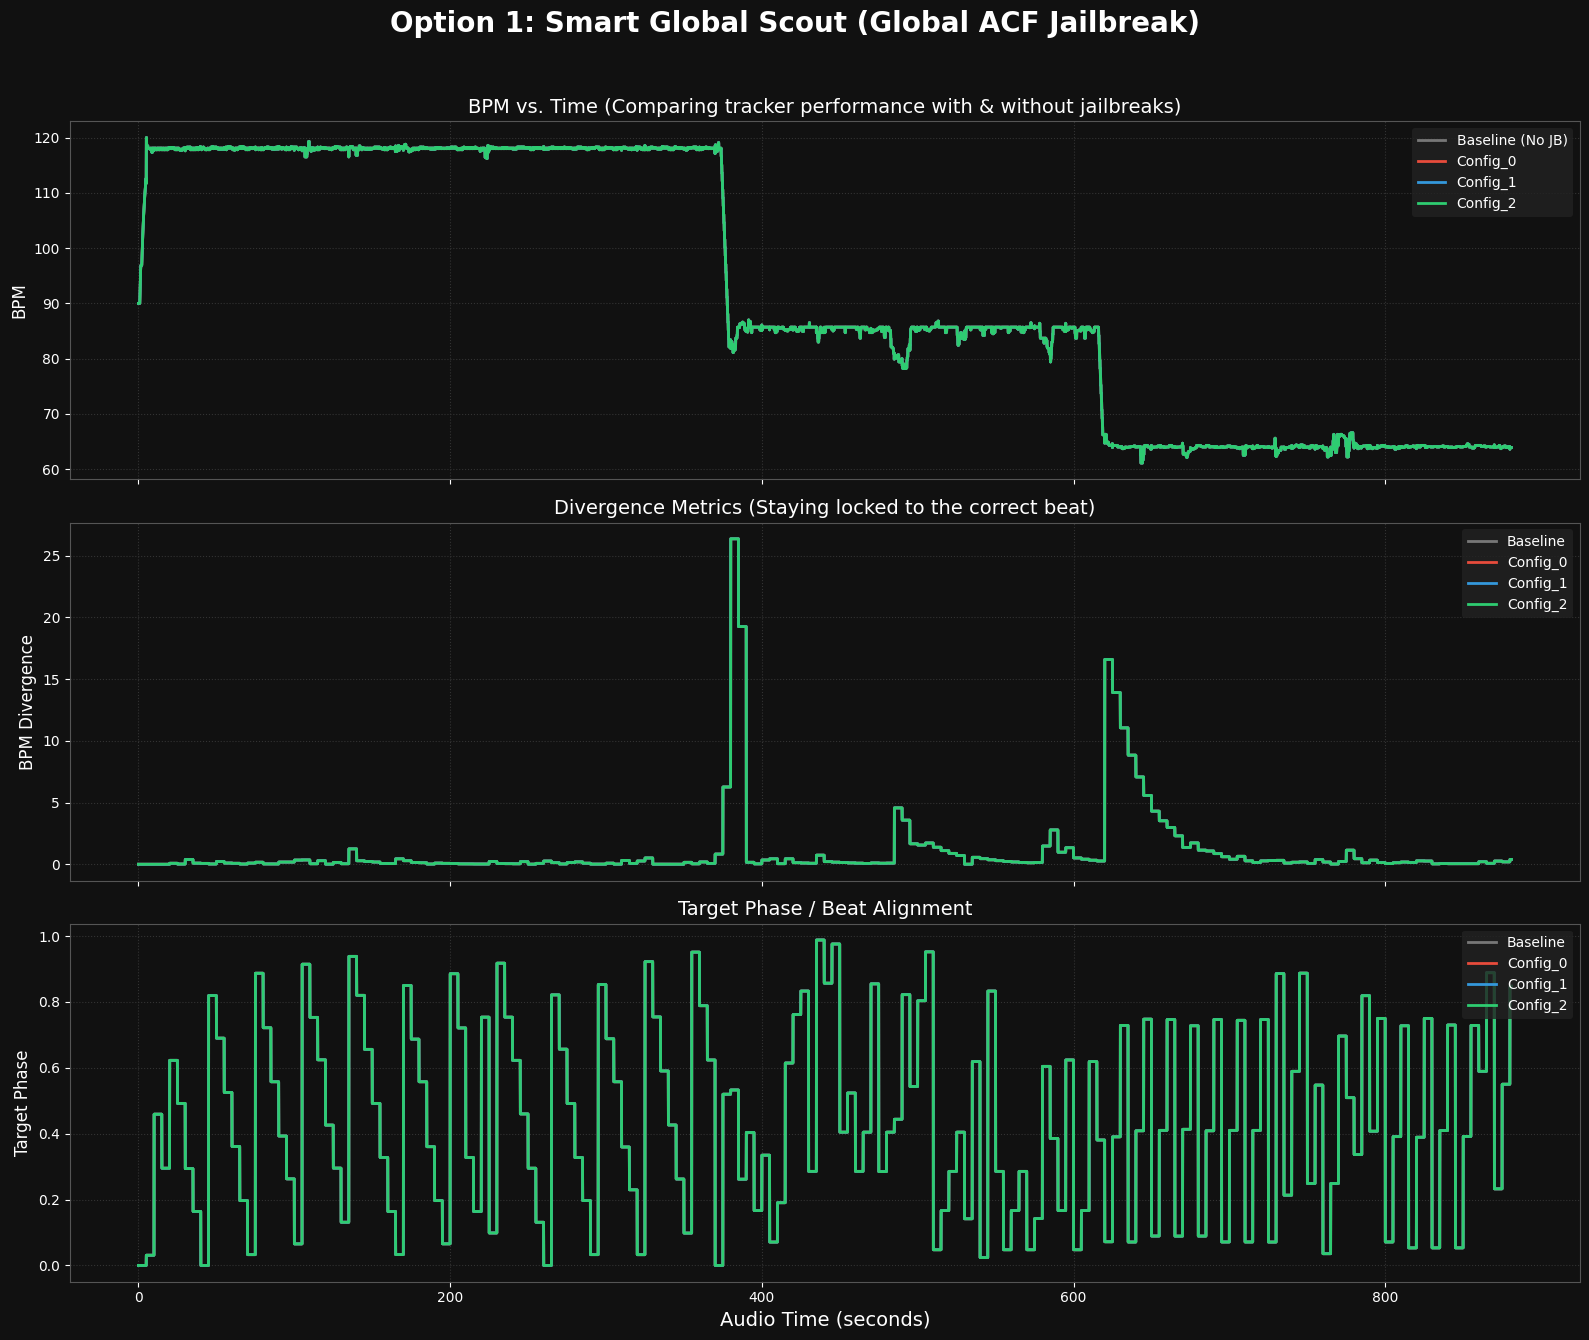

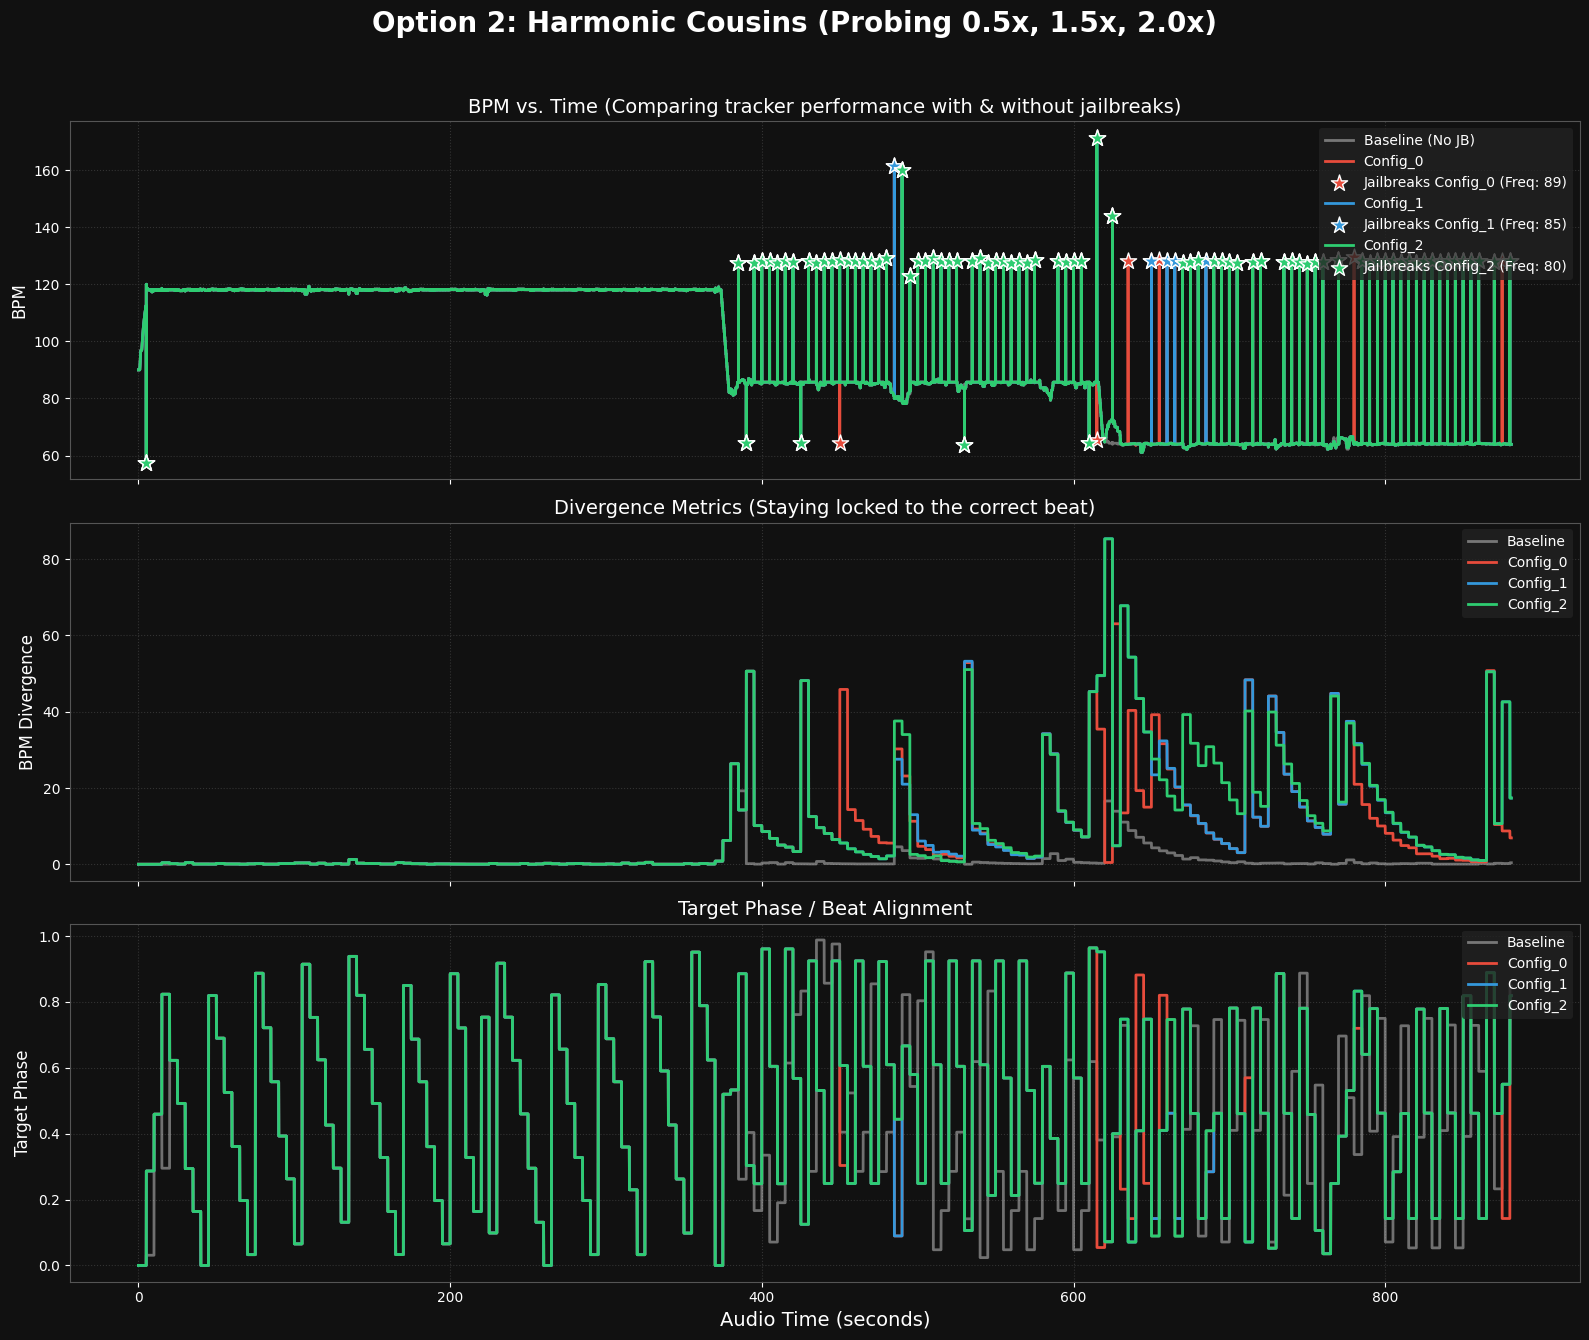

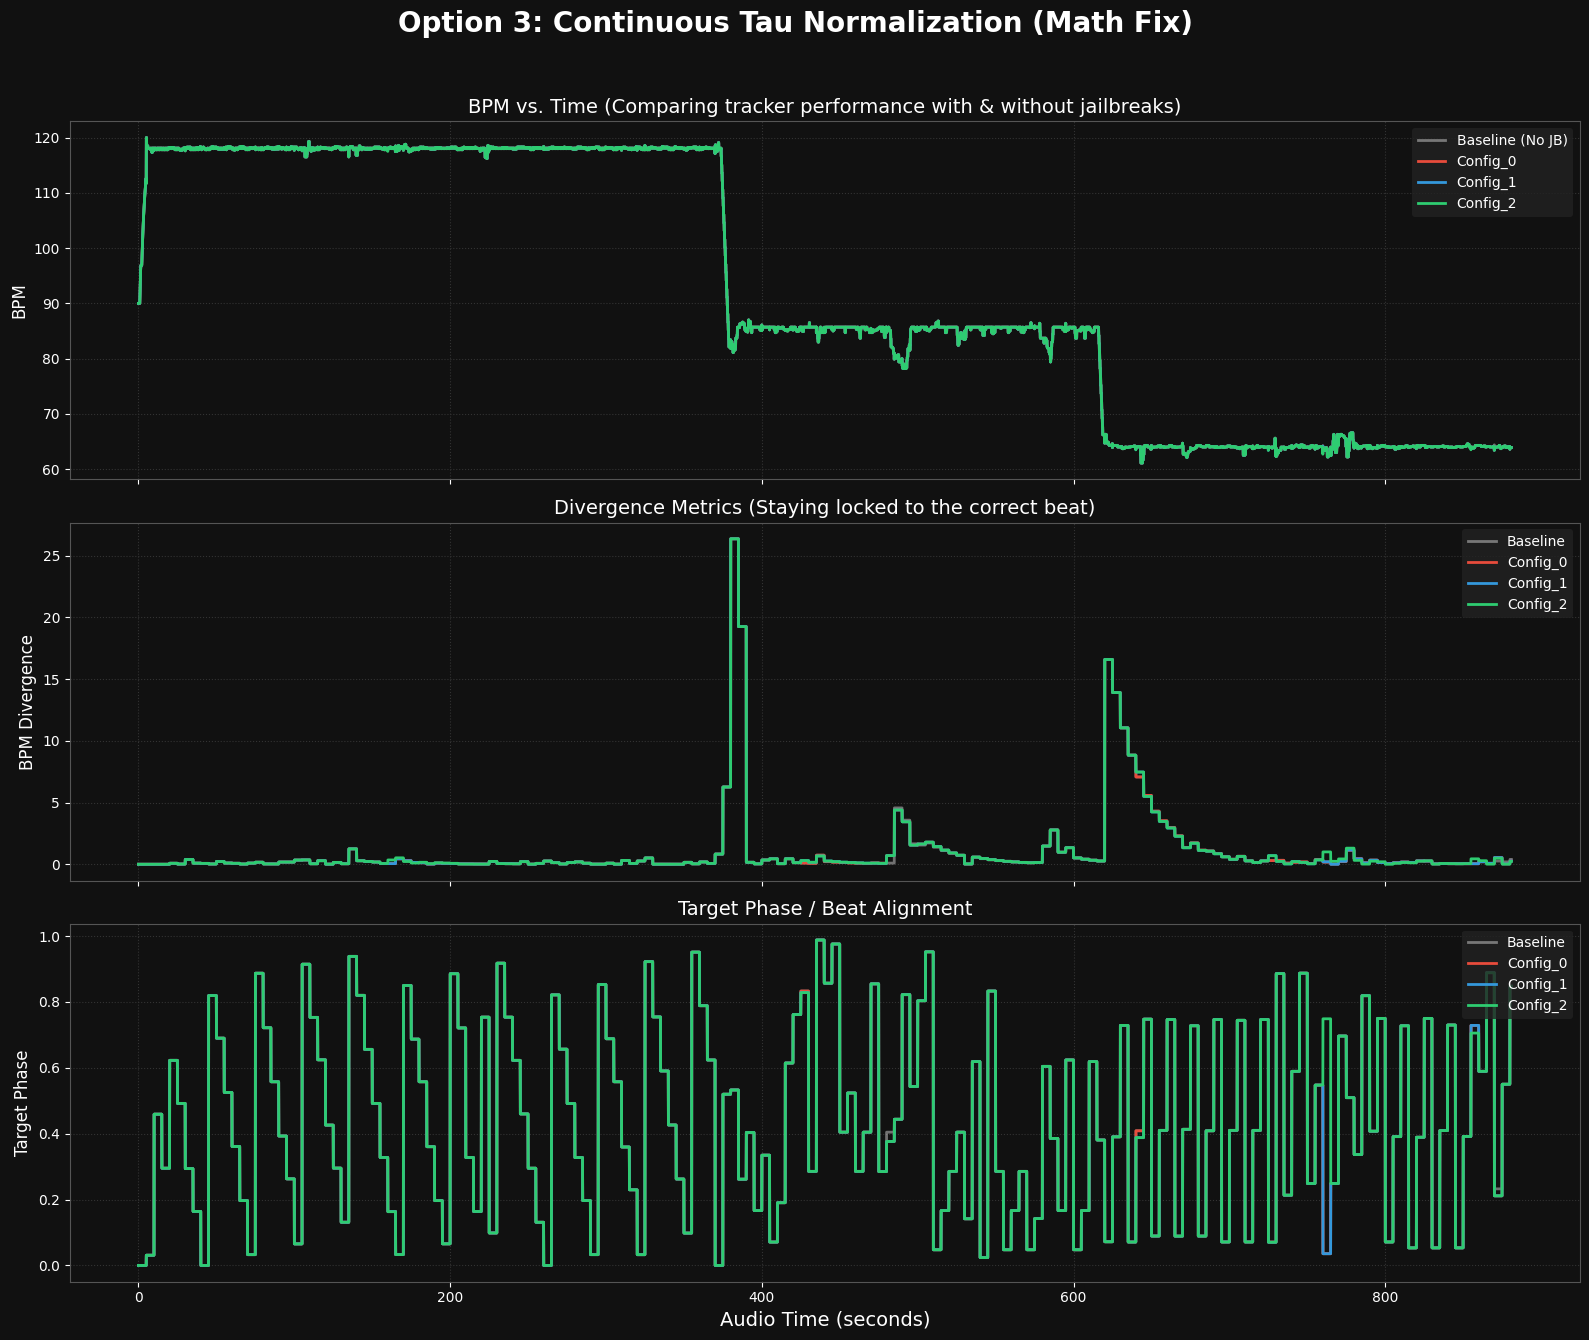

In [10]:
def plot_jailbreak_results(json_path="../assets/musics/mp3_files/librosa/jailbreak_options_results.json"):
    import matplotlib.pyplot as plt
    import numpy as np
    import json
    
    with open(json_path, 'r') as f:
        results = json.load(f)
        
    titles = {
        0: "Option 0: Baseline (Classic Flywheel Sweep)",
        1: "Option 1: Smart Global Scout (Global ACF Jailbreak)",
        2: "Option 2: Harmonic Cousins (Probing 0.5x, 1.5x, 2.0x)",
        3: "Option 3: Continuous Tau Normalization (Math Fix)"
    }
    
    base_data = results.get("Option_0_Config_0")
    t_base = np.array(base_data["history_time"]) if base_data else None
    
    real_bpms = [145, 128, 128]
    song_durations = [373.8666666666667, 239.61598639455784, 267.4986848072562]
    
    for opt_idx, title in titles.items():
        if opt_idx == 0:
            continue
            
        opt_keys = [k for k in results.keys() if k.startswith(f"Option_{opt_idx}_Config_")]
        if not opt_keys:
            continue
            
        fig, axes = plt.subplots(3, 1, figsize=(16, 15), sharex=True)
        fig.suptitle(title, fontsize=20, fontweight="bold", y=0.92, color="white")
        ax_bpm, ax_div, ax_phase = axes
        
        # Plot real BPMs
        current_time = 0.0
        for i, rbpm in enumerate(real_bpms):
            start_t = current_time
            end_t = current_time + song_durations[i]
            label = "Ground Truth BPM" if i == 0 else ""
            ax_bpm.hlines(y=rbpm, xmin=start_t, xmax=end_t, color="cyan", linestyle="-", linewidth=3, alpha=0.7, label=label)
            if i > 0:
                ax_bpm.axvline(x=start_t, color="gray", linestyle="--", alpha=0.5)
                ax_div.axvline(x=start_t, color="gray", linestyle="--", alpha=0.5)
                ax_phase.axvline(x=start_t, color="gray", linestyle="--", alpha=0.5)
            current_time += song_durations[i]
            
        if base_data is not None:
            ax_bpm.plot(t_base, base_data["history_bpm"], color="white", alpha=0.4, linewidth=2, label="Baseline (No JB)")
            ax_div.plot(t_base, base_data["history_bpm_divergence"], color="white", alpha=0.4, linewidth=2, label="Baseline")
            ax_phase.plot(t_base, base_data["history_target_phase"], color="white", alpha=0.4, linewidth=2, label="Baseline")
            
        colors = ["#e74c3c", "#3498db", "#2ecc71", "#f1c40f", "#9b59b6"]
        
        for i, res_key in enumerate(opt_keys):
            data = results[res_key]
            t = np.array(data["history_time"])
            bpm = np.array(data["history_bpm"])
            div = np.array(data["history_bpm_divergence"])
            phase = np.array(data["history_target_phase"])
            jb_times = np.array(data.get("jailbreak_times", []))
            jb_bpms = np.array(data.get("jailbreak_bpms", []))
            
            c = colors[i % len(colors)]
            label = res_key.replace(f"Option_{opt_idx}_", "")
            
            ax_bpm.plot(t, bpm, color=c, linewidth=2, label=label)
            ax_div.plot(t, div, color=c, linewidth=2, label=label)
            ax_phase.plot(t, phase, color=c, linewidth=2, label=label)
            
            if len(jb_times) > 0:
                ax_bpm.scatter(jb_times, jb_bpms, color=c, s=150, zorder=5, 
                               edgecolor="white", marker="*", label=f"Jailbreaks {label} (Freq: {len(jb_times)})")
                               
        for ax in axes:
            ax.grid(True, color="#333333", linestyle=":")
            ax.legend(loc="upper right", facecolor="#222222", edgecolor="none", labelcolor="white")
            ax.set_facecolor("#111111")
            ax.tick_params(colors="white")
            for spine in ax.spines.values():
                spine.set_color("#555555")
                
        fig.patch.set_facecolor("#111111")
        ax_bpm.set_title("BPM vs. Time (Comparing tracker performance with & without jailbreaks)", fontsize=14, color="white")
        ax_bpm.set_ylabel("BPM", fontsize=12, color="white")
        ax_div.set_title("Divergence Metrics (Staying locked to the correct beat)", fontsize=14, color="white")
        ax_div.set_ylabel("BPM Divergence", fontsize=12, color="white")
        ax_phase.set_title("Target Phase / Beat Alignment", fontsize=14, color="white")
        ax_phase.set_ylabel("Target Phase", fontsize=12, color="white")
        
        axes[-1].set_xlabel("Audio Time (seconds)", fontsize=14, color="white")
        plt.tight_layout(rect=[0, 0.03, 1, 0.90])
        plt.show()

# Run the plotter
plot_jailbreak_results()

### 6. BPM Performances

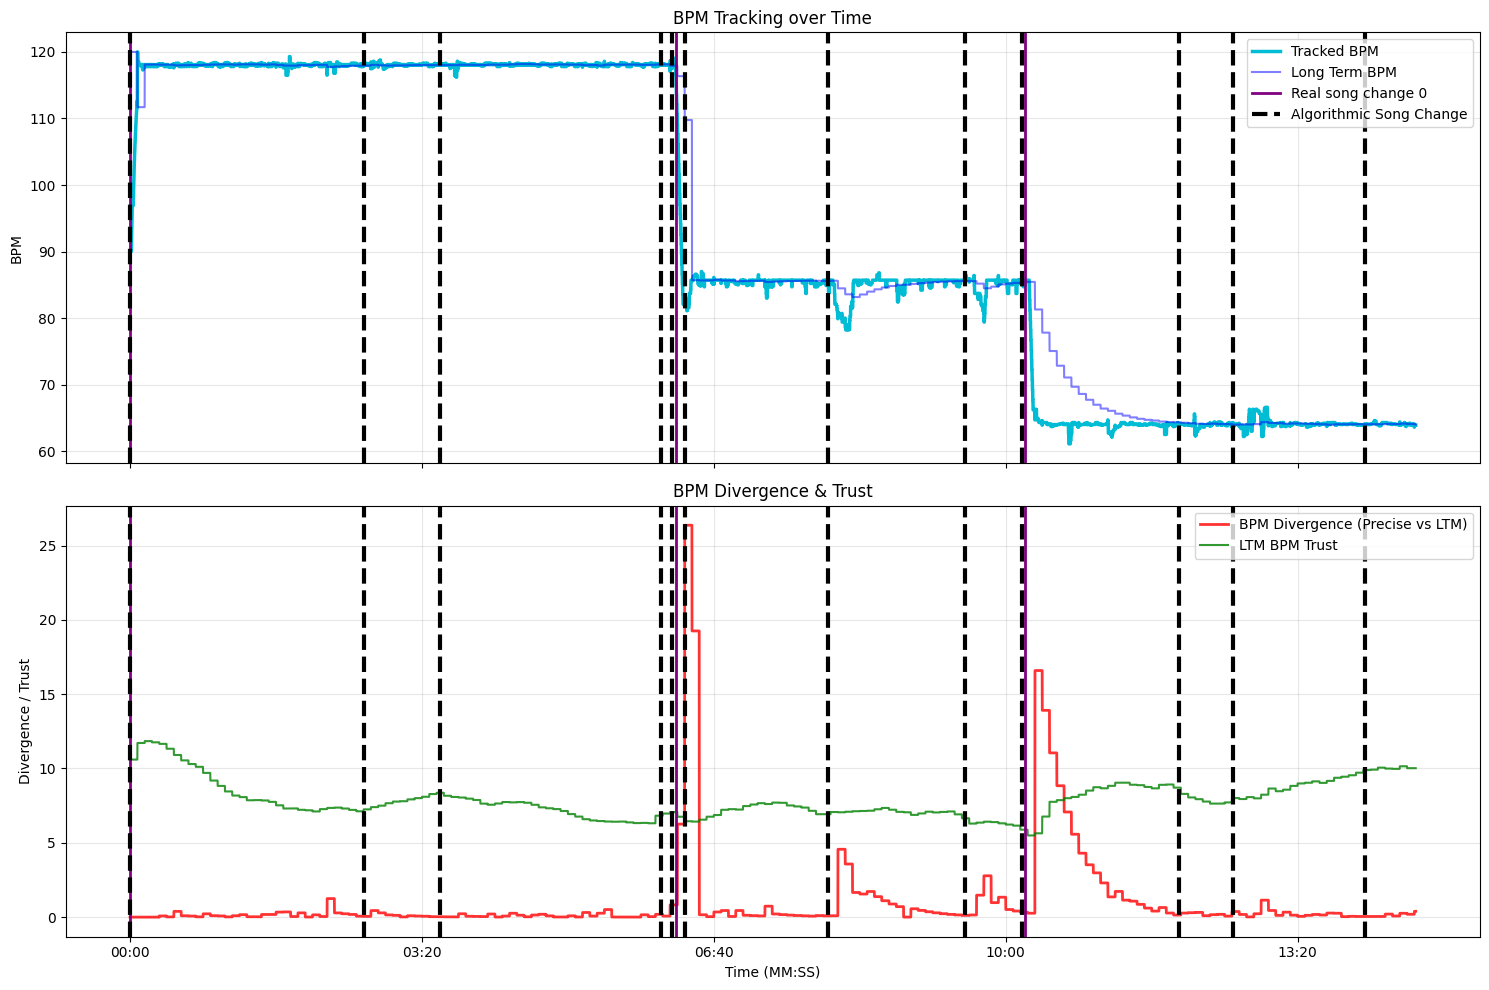

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
def min_sec_formatter(x, pos):
    m = int(x // 60)
    s = int(x % 60)
    return f'{m:02d}:{s:02d}'

time_arr = np.array(history_time)
bpm_arr = np.array(history_bpm)
trust_arr = np.array(history_trust)
diverge_arr = np.array(history_bpm_divergence)
ltm_bpm_arr = np.array(history_ltm_bpm)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 10), sharex=True)

ax1.plot(time_arr, bpm_arr, color='#00bcd4', linewidth=2.5, label='Tracked BPM')
ax1.plot(time_arr, ltm_bpm_arr, color='blue', alpha=0.5, linewidth=1.5, label='Long Term BPM')
ax1.set_title('BPM Tracking over Time')
ax1.set_ylabel('BPM')
ax1.legend(loc='upper right')
ax1.grid(alpha=0.3)

ax2.plot(time_arr, diverge_arr, color='red', alpha=0.8, linewidth=2.0, label='BPM Divergence (Precise vs LTM)')
ax2.plot(time_arr, 20.0*trust_arr, color='green', alpha=0.8, linewidth=1.5, label='LTM BPM Trust')
#ax2.axhline(8.0, color='darkred', linestyle='--', linewidth=2.0, label='BPM Jump Threshold (8.0)')
ax2.set_title('BPM Divergence & Trust')
ax2.set_ylabel('Divergence / Trust')
ax2.legend(loc='upper right')
ax2.grid(alpha=0.3)

y = 0
for k in range(len(y_list)):
    y_k = y_list[k]
    real_change_time = y / sr
    ax1.axvline(real_change_time, color='purple', linestyle='-', linewidth=2, label=f'Real song change {k}' if k==0 else '')
    ax2.axvline(real_change_time, color='purple', linestyle='-', linewidth=2)
    y += len(y_k)

for sid, s_time in enumerate(song_changes):
    ax1.axvline(s_time, color='black', linestyle='--', linewidth=3, label='Algorithmic Song Change' if sid == 0 else '')
    ax2.axvline(s_time, color='black', linestyle='--', linewidth=3)

ax1.legend(loc='upper right')
ax2.xaxis.set_major_formatter(ticker.FuncFormatter(min_sec_formatter))
plt.xlabel('Time (MM:SS)')
plt.tight_layout()
plt.savefig('bpm_performances.png')
plt.show()


### 7. Beat Detection/Prediction Performances

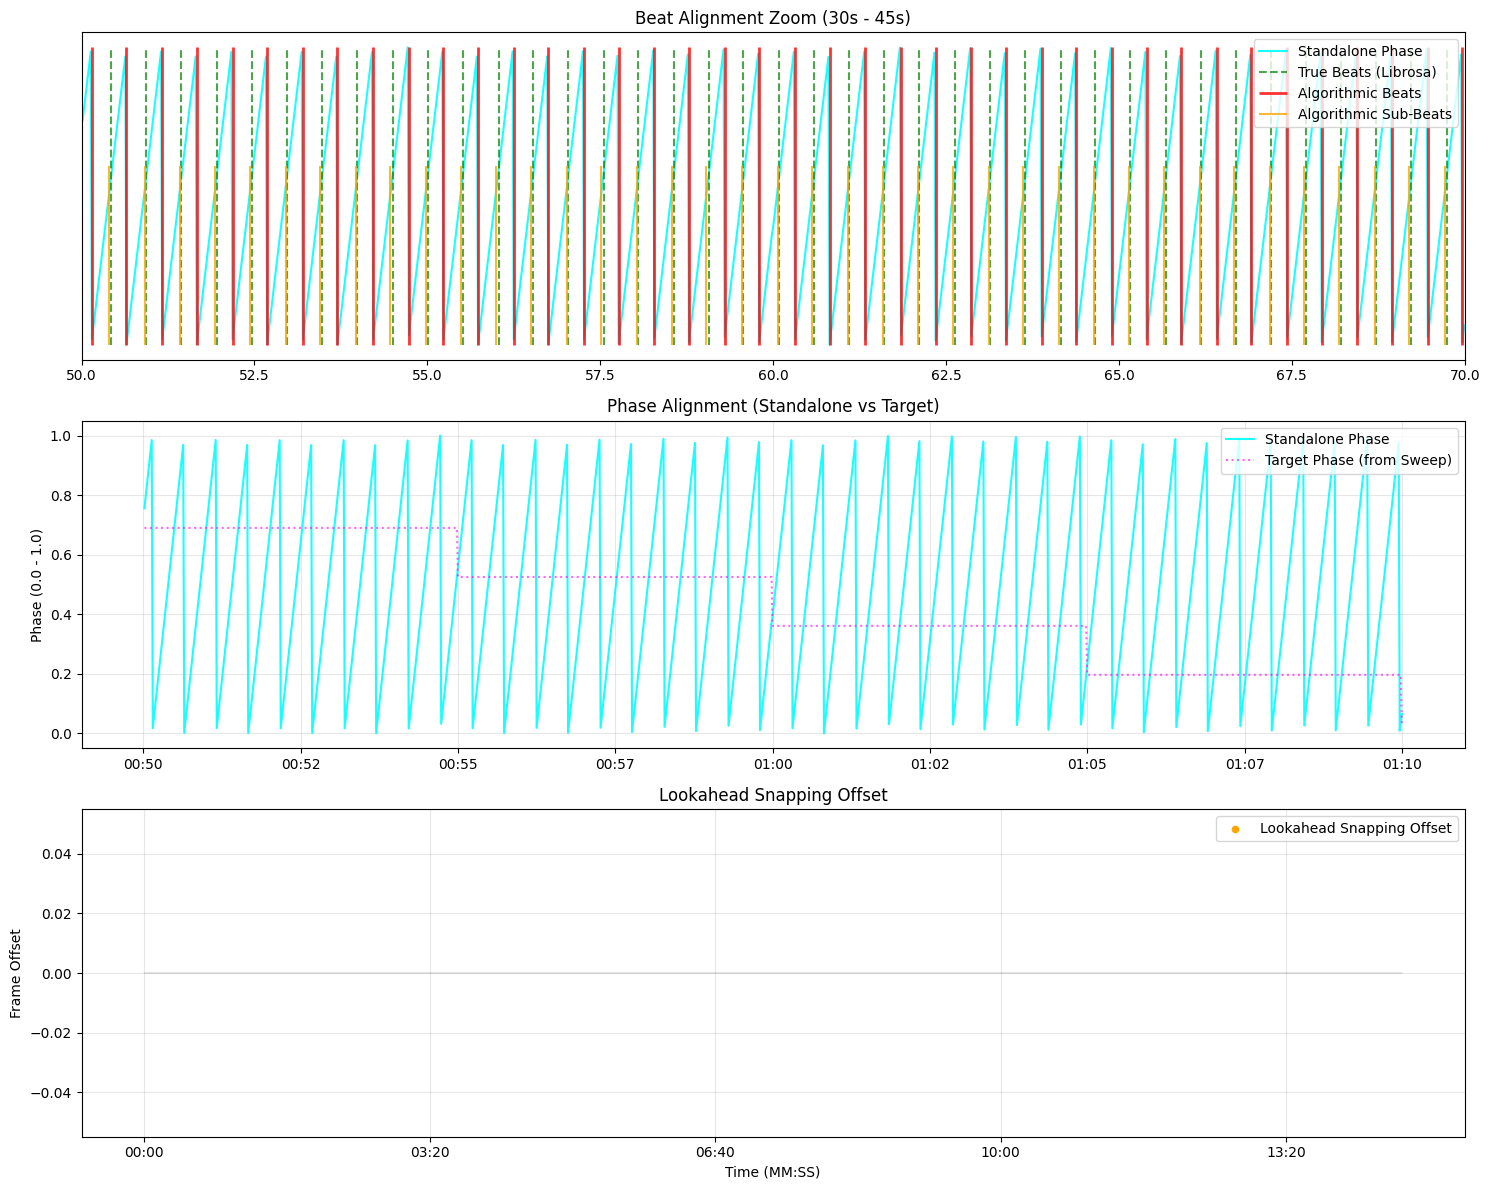

In [ ]:
stand_phase_arr = np.array(history_standalone_phase)
targ_phase_arr = np.array(history_target_phase)
snap_arr = np.array(history_snap_offset)

fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(15, 12), sharex=False)

# Flatten true beats from librosa
all_true_beats = np.concatenate(true_beat_times_list) if len(true_beat_times_list) > 0 else []

# Find a good window to zoom in (e.g. 30 to 45 seconds)
zoom_start = 50.0
zoom_end = 70.0
mask_true = (all_true_beats >= zoom_start) & (all_true_beats <= zoom_end)
mask_alg = (alg_beats_array >= zoom_start) & (alg_beats_array <= zoom_end)
mask_sub = (alg_sub_beats_array >= zoom_start) & (alg_sub_beats_array <= zoom_end)
time_true = (time_arr >= zoom_start) & (time_arr <= zoom_end)
ax1.plot(time_arr[time_true], stand_phase_arr[time_true], color='cyan', alpha=0.9, linewidth=1.5, label='Standalone Phase')
ax1.vlines(all_true_beats[mask_true], ymin=0, ymax=1, color='green', linestyle='--', alpha=0.7, label='True Beats (Librosa)')
ax1.vlines(alg_beats_array[mask_alg], ymin=0, ymax=1, color='red', linestyle='-', alpha=0.8, linewidth=2, label='Algorithmic Beats')
ax1.vlines(alg_sub_beats_array[mask_sub], ymin=0, ymax=0.6, color='orange', linestyle='-', alpha=0.8, linewidth=1.5, label='Algorithmic Sub-Beats')
ax1.set_xlim(zoom_start, zoom_end)
ax1.set_title('Beat Alignment Zoom (30s - 45s)')
ax1.set_yticks([])
ax1.legend(loc='upper right')

time_true = (time_arr >= zoom_start) & (time_arr <= zoom_end)
ax2.plot(time_arr[time_true], stand_phase_arr[time_true], color='cyan', alpha=0.9, linewidth=1.5, label='Standalone Phase')
ax2.plot(time_arr[time_true], targ_phase_arr[time_true], color='magenta', alpha=0.6, linewidth=1.5, linestyle=':', label='Target Phase (from Sweep)')
ax2.set_title('Phase Alignment (Standalone vs Target)')
ax2.set_ylabel('Phase (0.0 - 1.0)')
ax2.xaxis.set_major_formatter(ticker.FuncFormatter(min_sec_formatter))
ax2.legend(loc='upper right')
ax2.grid(alpha=0.3)

mask_snap = snap_arr != 0
ax3.plot(time_arr, snap_arr, color='grey', alpha=0.3, linewidth=1.0)
ax3.scatter(time_arr[mask_snap], snap_arr[mask_snap], color='orange', s=20, label='Lookahead Snapping Offset')
ax3.set_title('Lookahead Snapping Offset')
ax3.set_ylabel('Frame Offset')
ax3.set_xlabel('Time (MM:SS)')
ax3.xaxis.set_major_formatter(ticker.FuncFormatter(min_sec_formatter))
ax3.legend(loc='upper right')
ax3.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('beat_performances.png')
plt.show()


### 8. Song Change and Structural Change Performances

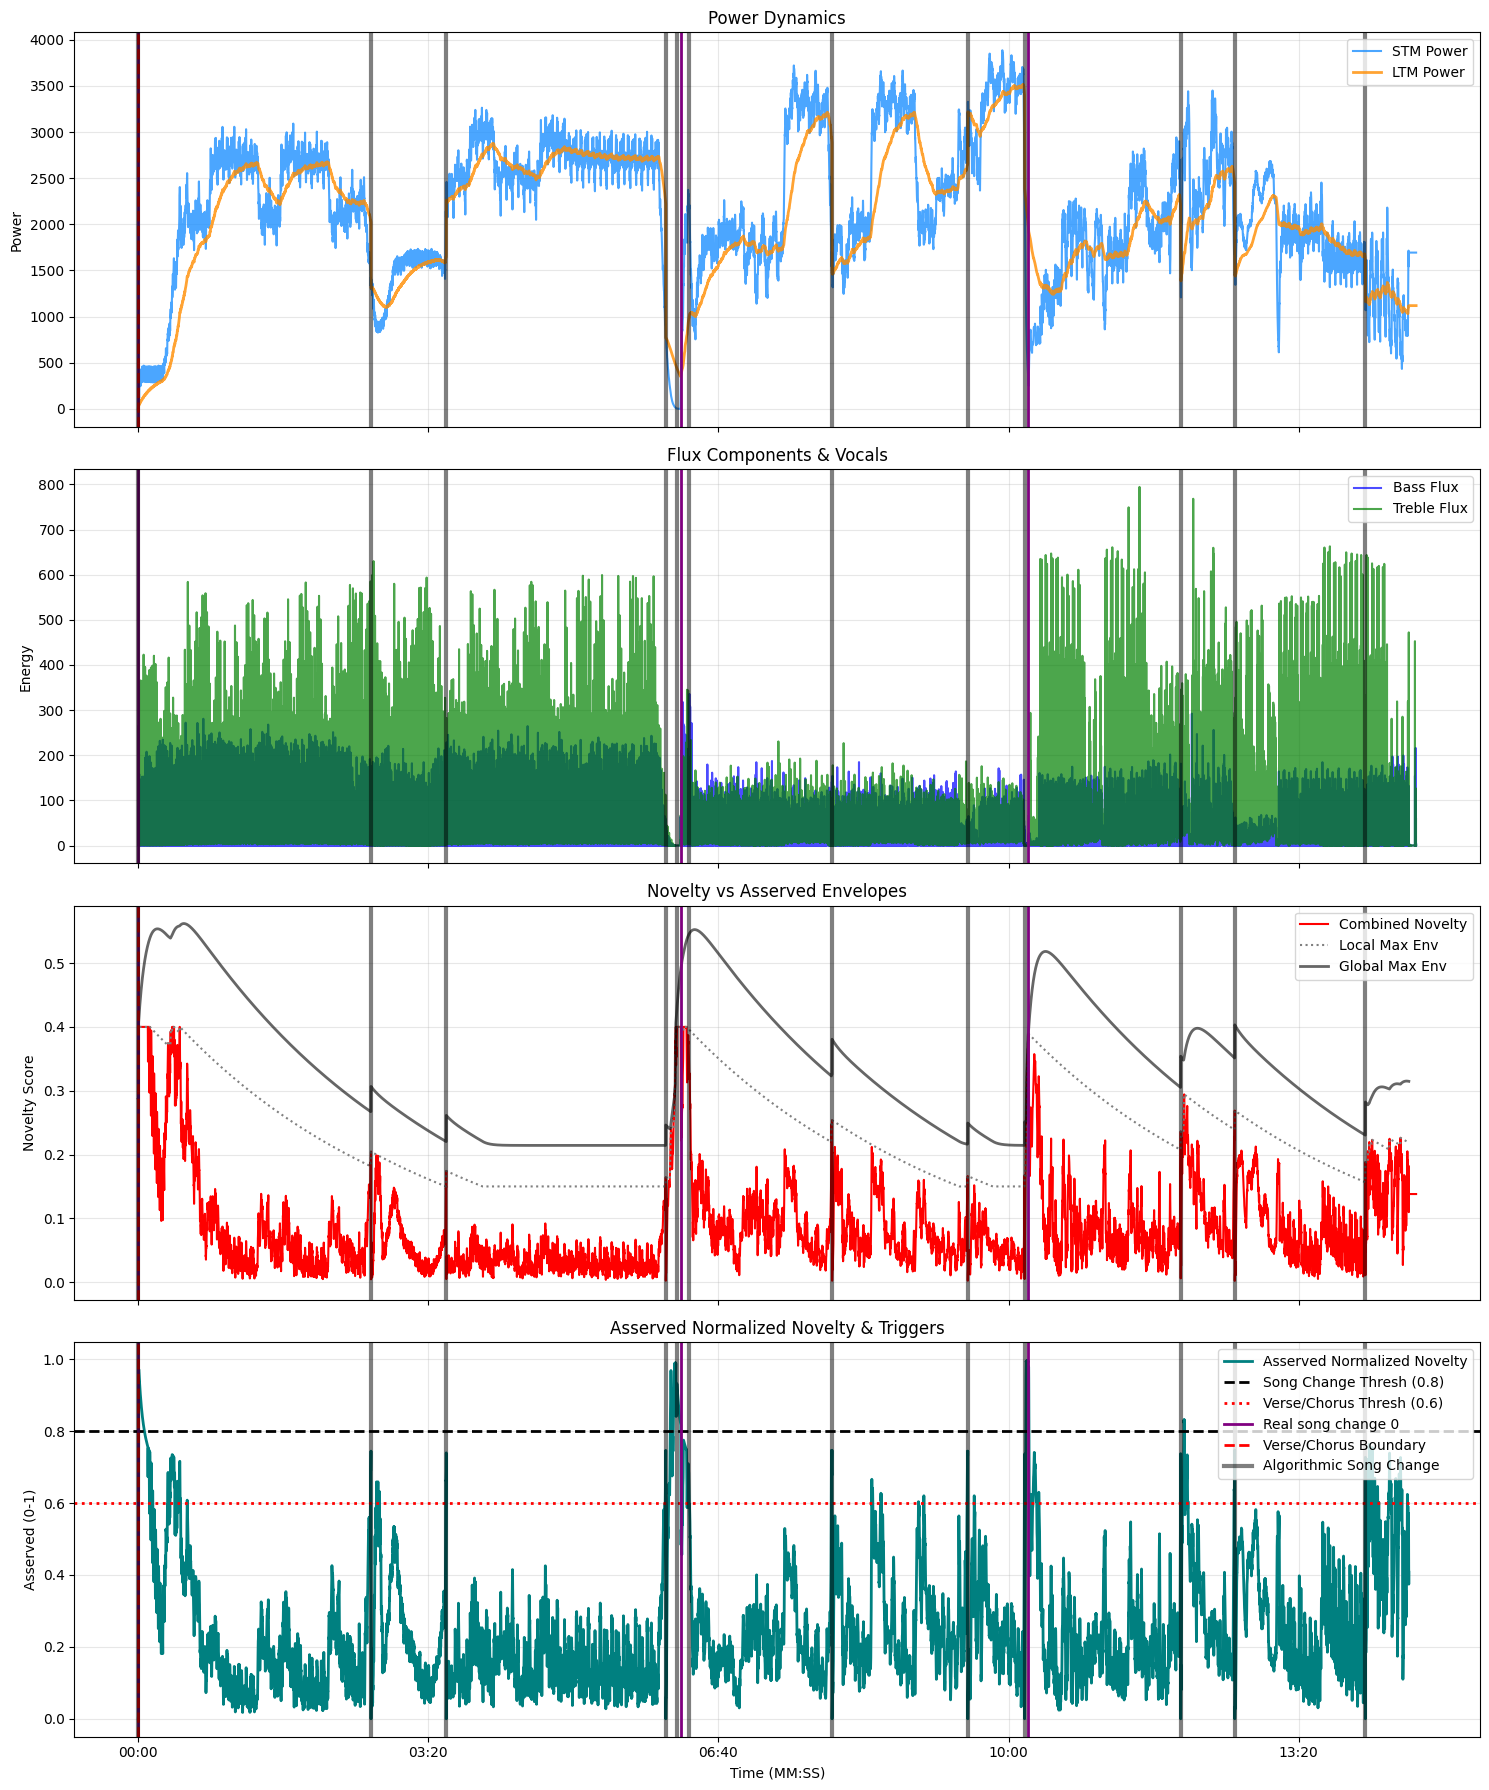

In [ ]:
stm_power_arr = np.array(history_stm_power)
ltm_power_arr = np.array(history_ltm_power)
timbral_nov_arr = np.array(history_timbral_nov)
power_nov_arr = np.array(history_power_nov)
combined_nov_arr = np.array(history_combined_nov)
nov_lm_arr = np.array(history_novelty_lm)
nov_gm_arr = np.array(history_novelty_gm)
asserved_nov_arr = np.array(history_asserved_nov)
bass_arr = np.array(history_bass)
treble_arr = np.array(history_treble)

fig, axes = plt.subplots(4, 1, figsize=(15, 18), sharex=True)
ax1, ax2, ax3, ax4 = axes

ax1.plot(time_arr, stm_power_arr, color='dodgerblue', alpha=0.8, linewidth=1.5, label='STM Power')
ax1.plot(time_arr, ltm_power_arr, color='darkorange', alpha=0.8, linewidth=2.0, label='LTM Power')
ax1.set_title('Power Dynamics')
ax1.set_ylabel('Power')
ax1.legend(loc='upper right')
ax1.grid(alpha=0.3)

ax2.plot(time_arr, bass_arr, color='blue', alpha=0.7, linewidth=1.5, label='Bass Flux')
ax2.plot(time_arr, treble_arr, color='green', alpha=0.7, linewidth=1.5, label='Treble Flux')
ax2.set_title('Flux Components & Vocals')
ax2.set_ylabel('Energy')
ax2.legend(loc='upper right')
ax2.grid(alpha=0.3)

ax3.plot(time_arr, combined_nov_arr, color='red', linewidth=1.5, label='Combined Novelty')
ax3.plot(time_arr[:len(nov_lm_arr)], nov_lm_arr, color='grey', linestyle=':', label='Local Max Env')
ax3.plot(time_arr[:len(nov_gm_arr)], nov_gm_arr, color='black', linewidth=2.0, alpha=0.6, label='Global Max Env')
ax3.set_title('Novelty vs Asserved Envelopes')
ax3.set_ylabel('Novelty Score')
ax3.legend(loc='upper right')
ax3.grid(alpha=0.3)

ax4.plot(time_arr[:len(asserved_nov_arr)], asserved_nov_arr, color='teal', linewidth=2.0, label='Asserved Normalized Novelty')
ax4.axhline(0.8, color='black', linestyle='--', linewidth=2.0, label='Song Change Thresh (0.8)')
ax4.axhline(0.6, color='red', linestyle=':', linewidth=2.0, label='Verse/Chorus Thresh (0.6)')
ax4.set_title('Asserved Normalized Novelty & Triggers')
ax4.set_xlabel('Time (MM:SS)')
ax4.set_ylabel('Asserved (0-1)')
ax4.legend(loc='upper right')
ax4.grid(alpha=0.3)

y = 0
for k in range(len(y_list)):
    y_k = y_list[k]
    real_change_time = y / sr
    for ax in axes:
        ax.axvline(real_change_time, color='purple', linestyle='-', linewidth=2, label=f'Real song change {k}' if k==0 else '')
    y += len(y_k)

for sid, s_time in enumerate(structural_changes):
    ax1.axvline(s_time, color='red', linestyle='--', linewidth=2)
    ax3.axvline(s_time, color='red', linestyle='--', linewidth=2)
    ax4.axvline(s_time, color='red', linestyle='--', linewidth=2, label='Verse/Chorus Boundary' if sid == 0 else '')

for sid, s_time in enumerate(song_changes):
    for ax in axes:
        ax.axvline(s_time, color='black', linestyle='-', linewidth=3, alpha=0.5, label='Algorithmic Song Change' if sid == 0 else '')

for ax in axes:
    ax.xaxis.set_major_formatter(ticker.FuncFormatter(min_sec_formatter))

ax4.legend(loc='upper right')
plt.tight_layout()
plt.savefig('structural_performances.png')
plt.show()
